# Diagnostic revenue — kết hợp orders + order_items + products + customers + geography + promotions + returns

Tầng **Diagnostic** (tại sao xảy ra?), nối tiếp `EDA_quan_sat.ipynb` (Descriptive). Chạy từng cell bằng **Shift+Enter**, nhớ chọn kernel `.venv`.

Cell đầu tiên load + join tất cả bảng — chạy 1 lần, dùng lại `li` (grain = 1 dòng/sản phẩm/đơn) cho toàn bộ phần sau. Sanity check khớp `sales.csv` để đảm bảo join không làm lệch số.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

DATA = Path("../../data")
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
items = pd.read_csv(DATA / "order_items.csv")
products = pd.read_csv(DATA / "products.csv", usecols=["product_id", "category", "cogs", "price"])
customers = pd.read_csv(DATA / "customers.csv", usecols=["customer_id", "acquisition_channel", "signup_date"])
geography = pd.read_csv(DATA / "geography.csv", usecols=["zip", "region"])
promotions = pd.read_csv(DATA / "promotions.csv",
                          usecols=["promo_id", "promo_type", "promo_channel", "discount_value",
                                   "start_date", "end_date"],
                          parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA / "returns.csv", usecols=["order_id", "refund_amount"])
sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
diff = ((chk.reindex(sales.set_index("Date")["Revenue"].index) - sales.set_index("Date")["Revenue"]).abs()
        / sales.set_index("Date")["Revenue"]).mean() * 100
print(f"{len(li):,} dòng order_items sau join | sai lệch rebuilt vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
OUT = Path("../output/phase2")
DATA_OUT = Path("data")
DATA_OUT.mkdir(parents=True, exist_ok=True)


## 1. Category — Streetwear ngày càng lấn át

Tỷ trọng dịch từ Outdoor sang Streetwear: 2013 Streetwear 76.8% → 2022 83.8%; Outdoor 19.8% → 9.0%. Danh mục ngày càng lệ thuộc 1 category duy nhất.

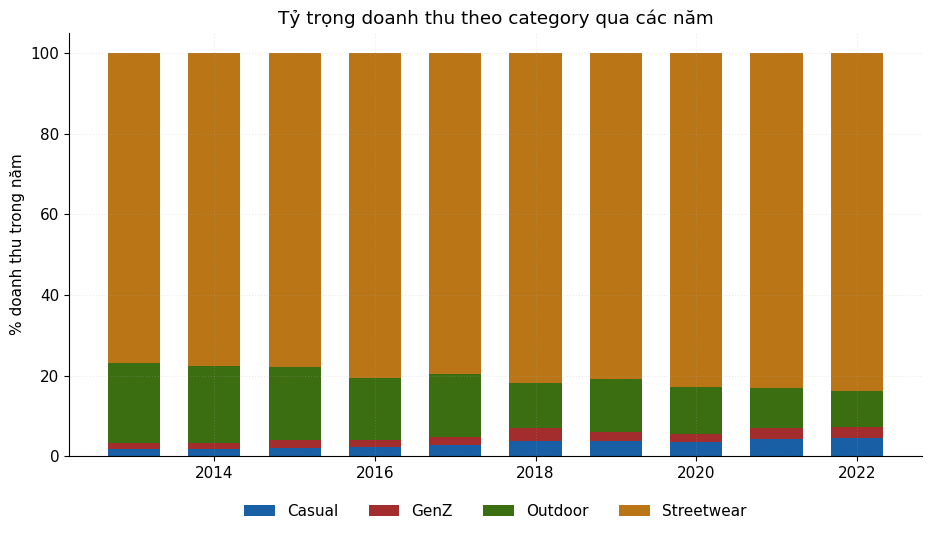

2013: {'Casual': 1.8, 'GenZ': 1.6, 'Outdoor': 19.8, 'Streetwear': 76.8}
2022: {'Casual': 4.6, 'GenZ': 2.5, 'Outdoor': 9.0, 'Streetwear': 83.8}


In [2]:
cat_yr = li.groupby(["year", "category"])["line_revenue"].sum().unstack()
cat_share = cat_yr.div(cat_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(cat_share))
for i, cat in enumerate(cat_share.columns):
    ax.bar(cat_share.index, cat_share[cat], bottom=bottom, label=cat,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += cat_share[cat].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo category qua các năm")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

print(f"2013: {cat_share.loc[2013].round(1).to_dict()}")
print(f"2022: {cat_share.loc[2022].round(1).to_dict()}")

## 2. Region — cả 3 vùng cùng nhịp

East dẫn đầu nhưng không vùng nào tách khỏi xu hướng chung → break 2019 là vấn đề hệ thống, không phải 1 khu vực.

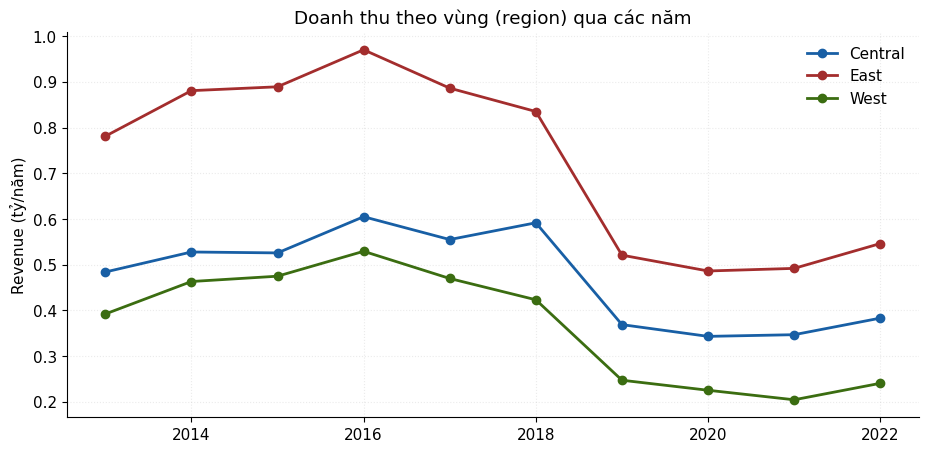

2022 (tỷ VND): {'Central': 0.38, 'East': 0.55, 'West': 0.24}


In [3]:
reg_yr = li.groupby(["year", "region"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
for i, reg in enumerate(reg_yr.columns):
    ax.plot(reg_yr.index, reg_yr[reg], "o-", color=PALETTE[i % len(PALETTE)], lw=2, label=reg)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo vùng (region) qua các năm")
ax.legend(frameon=False)
plt.show()

print(f"2022 (tỷ VND): {reg_yr.loc[2022].round(2).to_dict()}")

## 3. Khách mới vs khách cũ

Tỷ trọng doanh thu "khách cũ" (đơn không phải lần mua đầu tiên): 66.1% (2013) → 96.4% (2022).

Đọc đúng: đây là **tenure tích lũy** (pool khách lớn dần theo thời gian), **không phải** bằng chứng trung thành — tần suất mua trung bình toàn kỳ chỉ 1.83 đơn/khách (đã chốt Phase 0). Đáng chú ý hơn: nhìn tổng chiều cao cột, doanh thu từ khách MỚI gần như biến mất sau 2019.

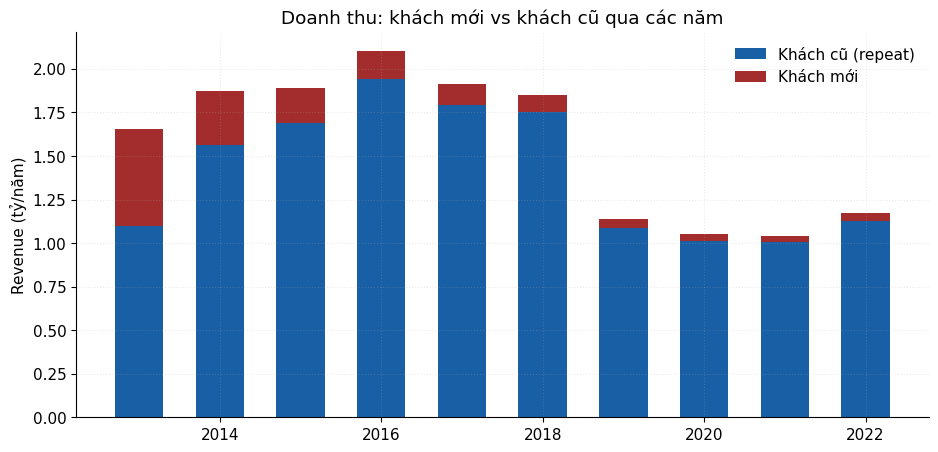

Tỷ trọng khách cũ — 2013: 66.1% | 2018: 94.7% | 2019: 95.6% | 2022: 96.4%


In [4]:
first_order = orders.groupby("customer_id")["order_date"].min().rename("first_order_date")
li2 = li.merge(first_order, on="customer_id", how="left")
li2["cust_type"] = np.where(li2["order_date"] == li2["first_order_date"], "Khách mới", "Khách cũ (repeat)")
nr_yr = li2.groupby(["year", "cust_type"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(nr_yr.index, nr_yr["Khách cũ (repeat)"], color=C_COGS, label="Khách cũ (repeat)", width=0.6)
ax.bar(nr_yr.index, nr_yr["Khách mới"], bottom=nr_yr["Khách cũ (repeat)"], color=C_REV, label="Khách mới", width=0.6)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu: khách mới vs khách cũ qua các năm")
ax.legend(frameon=False)
plt.show()

repeat_share = (nr_yr["Khách cũ (repeat)"] / nr_yr.sum(axis=1) * 100)
print(f"Tỷ trọng khách cũ — 2013: {repeat_share.loc[2013]:.1f}% | 2018: {repeat_share.loc[2018]:.1f}% | "
      f"2019: {repeat_share.loc[2019]:.1f}% | 2022: {repeat_share.loc[2022]:.1f}%")

## 4. Waterfall: Gross booked → Net thực thu

"Revenue" trong `sales.csv` là số ghi nhận gộp — không phải tiền thực về. Hao hụt lớn nhất đến từ hủy đơn (9.2%), gấp đôi discount, gấp ~3 lần refund.

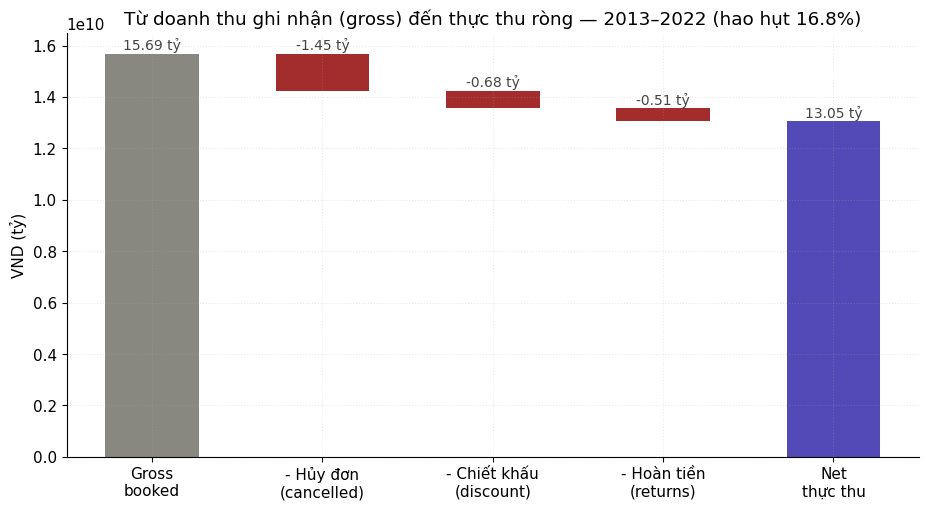

Gross 15.69 tỷ | -Hủy đơn 9.2% | -Chiết khấu 4.3% | -Hoàn tiền 3.3% | = Net 13.05 tỷ (83.2% gross)


In [5]:
gross = li["line_revenue"].sum()
cancelled_loss = li.loc[li["order_status"] == "cancelled", "line_revenue"].sum()
after_cancel = gross - cancelled_loss
discount_loss = li.loc[li["order_status"] != "cancelled", "discount_amount"].sum()
after_discount = after_cancel - discount_loss
refund_loss = returns["refund_amount"].sum()
net_final = after_discount - refund_loss

stages = ["Gross\nbooked", "- Hủy đơn\n(cancelled)", "- Chiết khấu\n(discount)", "- Hoàn tiền\n(returns)", "Net\nthực thu"]
values = [gross, -cancelled_loss, -discount_loss, -refund_loss, net_final]
cum = [gross, after_cancel, after_discount, net_final, net_final]
bar_bottoms = [0, after_cancel, after_discount, net_final, 0]
bar_heights = [gross, cancelled_loss, discount_loss, refund_loss, net_final]
colors = [C_GRAY, C_REV, C_REV, C_REV, C_ACCENT]

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, (s, h, c) in enumerate(zip(bar_bottoms, bar_heights, colors)):
    ax.bar(i, h, bottom=s, color=c, width=0.55)
    label = f"{cum[i]/1e9:.2f} tỷ" if i in (0, 4) else f"{values[i]/1e9:+.2f} tỷ"
    ax.text(i, s + h + gross * 0.01, label, ha="center", fontsize=10, color="#444441")
ax.set_xticks(range(5), stages)
ax.set_ylabel("VND (tỷ)")
ax.set_title(f"Từ doanh thu ghi nhận (gross) đến thực thu ròng — 2013–2022 (hao hụt {(1-net_final/gross)*100:.1f}%)")
plt.show()

print(f"Gross {gross/1e9:.2f} tỷ | -Hủy đơn {cancelled_loss/gross*100:.1f}% | "
      f"-Chiết khấu {discount_loss/gross*100:.1f}% | -Hoàn tiền {refund_loss/gross*100:.1f}% | "
      f"= Net {net_final/1e9:.2f} tỷ ({net_final/gross*100:.1f}% gross)")

## 5. Kênh order_source

Cả 6 kênh gãy cùng lúc năm 2019 — xác nhận thêm break là vấn đề retention hệ thống, không phải 1 kênh marketing yếu đi.

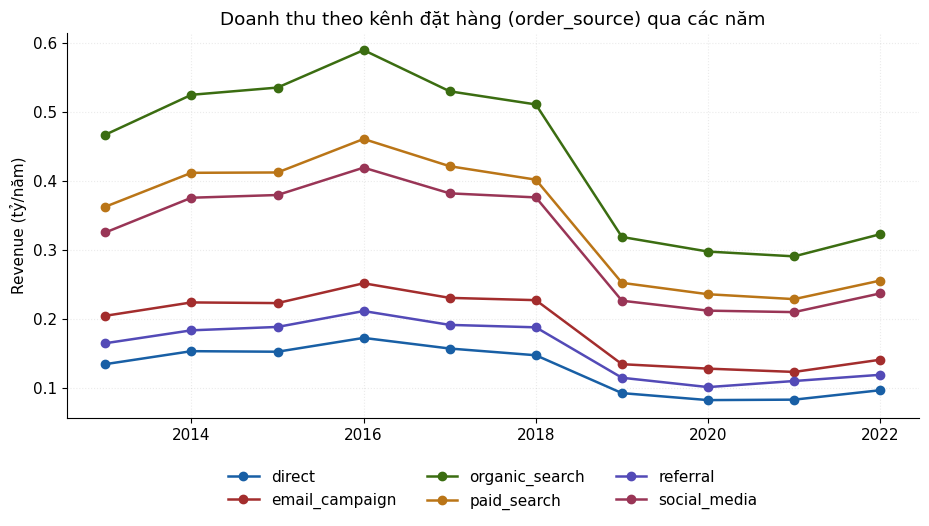

2022 (tỷ VND): {'direct': 0.1, 'email_campaign': 0.14, 'organic_search': 0.32, 'paid_search': 0.26, 'referral': 0.12, 'social_media': 0.24}


In [6]:
src_yr = li.groupby(["year", "order_source"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
for i, src in enumerate(src_yr.columns):
    ax.plot(src_yr.index, src_yr[src], "o-", color=PALETTE[i % len(PALETTE)], lw=1.8, label=src)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo kênh đặt hàng (order_source) qua các năm")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
plt.show()

print(f"2022 (tỷ VND): {src_yr.loc[2022].round(2).to_dict()}")

## 6. LTV theo acquisition_channel

Revenue trung bình/khách gần như bằng nhau giữa mọi kênh (0.17–0.18 triệu, chênh <6%) → `acquisition_channel` không phân hoá chất lượng khách trong data này. Nên tối ưu theo chi phí kênh, không theo kỳ vọng "kênh xịn hơn".

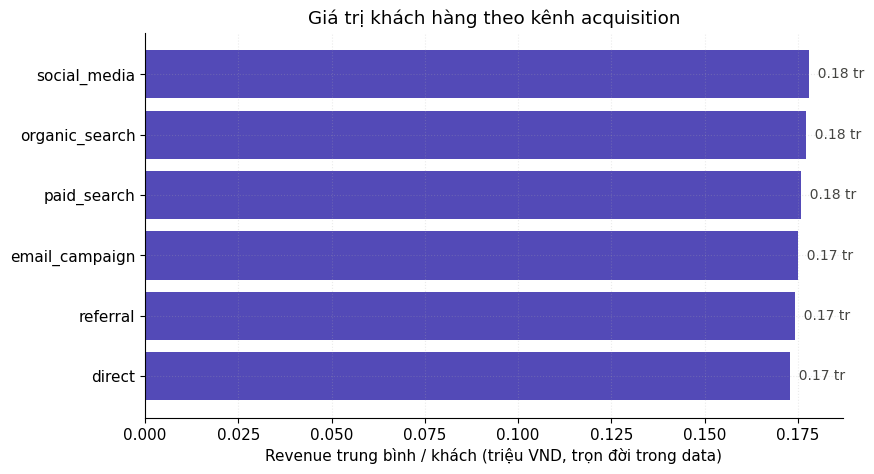

LTV theo kênh (triệu VND/khách): {'direct': 0.173, 'referral': 0.174, 'email_campaign': 0.175, 'paid_search': 0.176, 'organic_search': 0.177, 'social_media': 0.178}


In [7]:
cust_rev = li.groupby("customer_id")["line_revenue"].sum().rename("total_revenue")
cust_ch = customers.set_index("customer_id")["acquisition_channel"]
ltv = cust_rev.to_frame().join(cust_ch).groupby("acquisition_channel")["total_revenue"].mean().sort_values() / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ltv.index, ltv.values, color=C_ACCENT)
for i, v in enumerate(ltv.values):
    ax.text(v, i, f"  {v:.2f} tr", va="center", fontsize=10, color="#444441")
ax.set_xlabel("Revenue trung bình / khách (triệu VND, trọn đời trong data)")
ax.set_title("Giá trị khách hàng theo kênh acquisition")
plt.show()

print(f"LTV theo kênh (triệu VND/khách): {ltv.round(3).to_dict()}")

## 7. Payment method

Cơ cấu gần như đứng yên suốt 10 năm (credit_card ~55%, paypal ~15%, cod ~15%, apple_pay ~10%, bank_transfer ~5%) — feature gần như hằng số, không đáng đưa vào model Phần B.

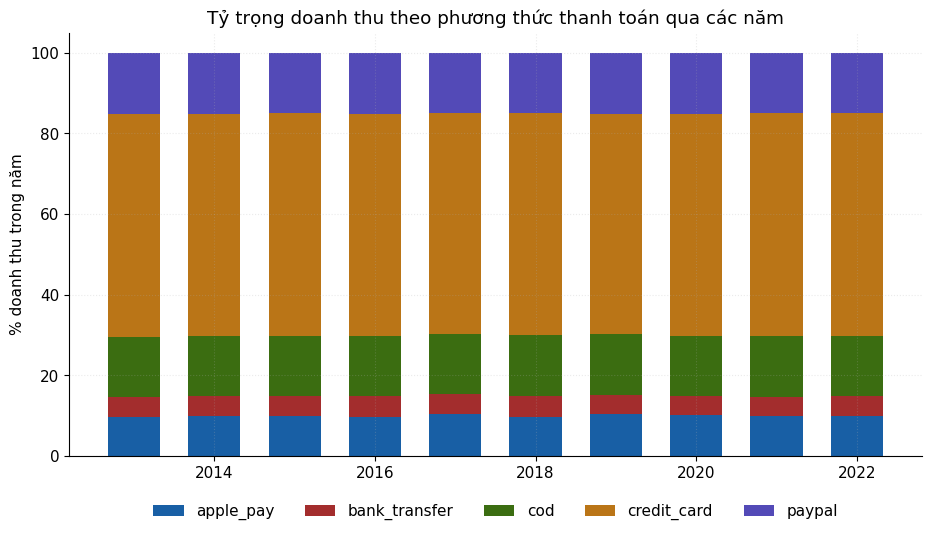

2013: {'apple_pay': 9.8, 'bank_transfer': 4.9, 'cod': 14.9, 'credit_card': 55.2, 'paypal': 15.2}
2022: {'apple_pay': 9.9, 'bank_transfer': 5.1, 'cod': 14.9, 'credit_card': 55.2, 'paypal': 15.0}


In [8]:
pay_yr = li.groupby(["year", "payment_method"])["line_revenue"].sum().unstack()
pay_share = pay_yr.div(pay_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(pay_share))
for i, pm in enumerate(pay_share.columns):
    ax.bar(pay_share.index, pay_share[pm], bottom=bottom, label=pm,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += pay_share[pm].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo phương thức thanh toán qua các năm")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.show()

print(f"2013: {pay_share.loc[2013].round(1).to_dict()}")
print(f"2022: {pay_share.loc[2022].round(1).to_dict()}")

## 8. Hiệu ứng khuyến mãi

Nghịch lý: AOV đơn có promo **thấp hơn** đơn không promo 21.6%. Chưa giải thích được — nghi vấn promo đang gắn với hàng thanh lý/giá thấp, cần module RFM/Predictive đào tiếp.

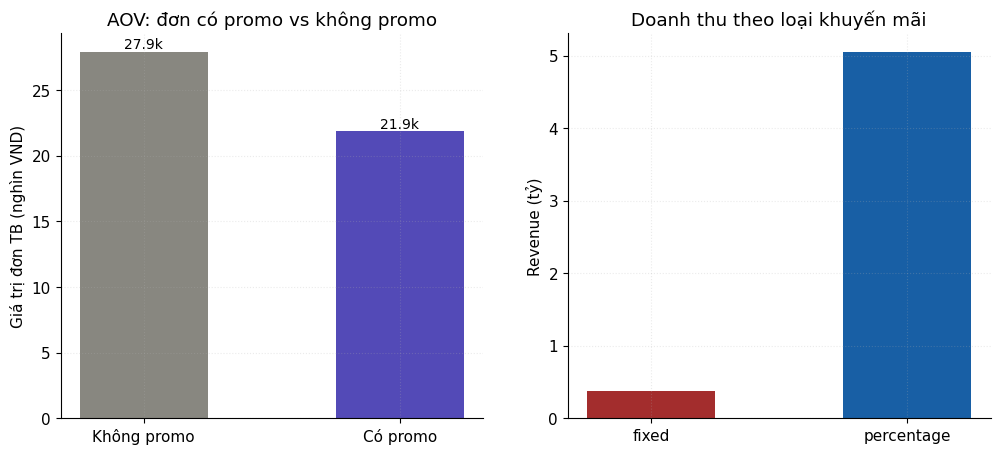

AOV không promo: 27,945 VND | AOV có promo: 21,896 VND (chênh -21.6%)
Revenue theo promo_type (tỷ): {'fixed': 0.38, 'percentage': 5.06}


In [9]:
li["has_promo"] = li["promo_id"].notna()
order_val = li.groupby(["order_id", "has_promo"])["line_revenue"].sum().reset_index()
aov = order_val.groupby("has_promo")["line_revenue"].mean()
promo_type_rev = li[li["has_promo"]].groupby("promo_type")["line_revenue"].sum() / 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(["Không promo", "Có promo"], aov.values / 1e3, color=[C_GRAY, C_ACCENT], width=0.5)
for i, v in enumerate(aov.values / 1e3):
    ax1.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax1.set_title("AOV: đơn có promo vs không promo")

ax2.bar(promo_type_rev.index, promo_type_rev.values, color=[C_REV, C_COGS], width=0.5)
ax2.set_ylabel("Revenue (tỷ)")
ax2.set_title("Doanh thu theo loại khuyến mãi")
plt.show()

print(f"AOV không promo: {aov[False]:,.0f} VND | AOV có promo: {aov[True]:,.0f} VND "
      f"(chênh {(aov[True]/aov[False]-1)*100:+.1f}%)")
print(f"Revenue theo promo_type (tỷ): {promo_type_rev.round(2).to_dict()}")

## 9. Vì sao 2019-2021 sụt mạnh? — Tách giá (ASP) vs khối lượng

Revenue 2018→2019 rơi **-38.6%**. Decompose: ASP (giá bán bình quân/đơn vị) **+2.4%** (không giảm, thậm chí tăng nhẹ), trong khi qty **-40.0%**, số đơn **-40.2%**, khách active **-28.0%**. → Nguyên nhân là **khối lượng sụp** (ít đơn hơn, ít khách mua hơn), **KHÔNG PHẢI** giảm giá bán.

In [ ]:
yr_kpi = li.groupby("year").agg(revenue=("line_revenue", "sum"), qty=("quantity", "sum")).reset_index()
yr_kpi["ASP"] = yr_kpi["revenue"] / yr_kpi["qty"]

ord_all = orders.assign(year=orders["order_date"].dt.year)
ord_all = ord_all[ord_all["year"].between(2013, 2022)]
n_orders = ord_all.groupby("year")["order_id"].nunique().rename("n_orders")
n_active_cust = ord_all.groupby("year")["customer_id"].nunique().rename("n_active_cust")
yr_kpi = yr_kpi.merge(n_orders, on="year").merge(n_active_cust, on="year")
yr_kpi["AOV"] = yr_kpi["revenue"] / yr_kpi["n_orders"]
yr_kpi.to_csv(DATA_OUT / "yearly_kpi_decompose.csv", index=False)

base = yr_kpi.set_index("year")
r18, r19 = base.loc[2018], base.loc[2019]
d_revenue = (r19["revenue"] / r18["revenue"] - 1) * 100
d_asp = (r19["ASP"] / r18["ASP"] - 1) * 100
d_qty = (r19["qty"] / r18["qty"] - 1) * 100
d_orders = (r19["n_orders"] / r18["n_orders"] - 1) * 100
d_cust = (r19["n_active_cust"] / r18["n_active_cust"] - 1) * 100
d_aov = (r19["AOV"] / r18["AOV"] - 1) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
idx = base.index
ax1.plot(idx, base["revenue"] / 1e9, "o-", color=C_REV, lw=2, label="Revenue (tỷ)")
ax1.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax1.set_ylabel("Revenue (tỷ VND)"); ax1.set_title("Revenue theo năm — break 2019")
ax1b = ax1.twinx()
ax1b.plot(idx, base["ASP"], "s--", color=C_ACCENT, lw=1.6, label="ASP (giá bán TB/đơn vị)")
ax1b.set_ylabel("ASP (VND/đơn vị)", color=C_ACCENT)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, frameon=False, loc="upper right", fontsize=9)

idx100 = base / base.loc[2018] * 100
for col, c, lbl in [("qty", C_COGS, "Số lượng bán (qty)"), ("n_orders", C_REV, "Số đơn"),
                     ("n_active_cust", C_ACCENT, "Khách active"), ("ASP", "#3B6D11", "ASP")]:
    ax2.plot(idx, idx100[col], "o-", color=c, lw=1.8, label=lbl)
ax2.axhline(100, color=C_GRAY, ls=":", lw=1)
ax2.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax2.set_ylabel("Index (2018 = 100)"); ax2.set_title("Volume rơi mạnh, ASP KHÔNG giảm (index 2018=100)")
ax2.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "29_yearly_price_volume_decompose.png", dpi=110); plt.close(fig)

print("=== 15. Q1 — Decompose YoY 2018→2019 ===")
print(f"  Revenue {d_revenue:+.1f}% | ASP {d_asp:+.1f}% | Qty {d_qty:+.1f}% | "
      f"Số đơn {d_orders:+.1f}% | Khách active {d_cust:+.1f}% | AOV {d_aov:+.1f}%")
print("  -> ASP KHÔNG giảm (thậm chí tăng nhẹ); sụt giảm gần như toàn bộ đến từ khối lượng"
      " (qty/số đơn) rơi ~40%, khách active rơi ~28%.\n")


## 10. Cường độ khuyến mãi theo năm — có phải do promo đổi khác 2019?

Join `order_items`+`promotions` theo `promo_id` (FK sạch 100% theo QC). % doanh thu có promo dao động theo chu kỳ lẻ/chẵn năm (~38-40% năm lẻ do có thêm Rural/Urban Special, ~30-32% năm chẵn) — **2019 nằm đúng nhịp năm lẻ bình thường**, không có bất thường tại 2019 → loại bỏ giả thuyết "đổi mix/cường độ promo gây break".

In [ ]:
li["has_promo"] = li["promo_id"].notna()
promo_line_rev = li.loc[li["has_promo"]].groupby("year")["line_revenue"].sum()
total_rev_yr = li.groupby("year")["line_revenue"].sum()
avg_discount_active = li.loc[li["has_promo"]].groupby("year")["discount_value"].mean()

promo_rev = pd.DataFrame({
    "pct_revenue_with_promo": (promo_line_rev / total_rev_yr * 100),
    "pct_lineitems_with_promo": li.groupby("year")["has_promo"].mean() * 100,
    "avg_discount_value_active_pct": avg_discount_active,
})
active_counts = {}
for y in range(2013, 2023):
    y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
    active_counts[y] = int(((promotions["start_date"] <= y_end) & (promotions["end_date"] >= y_start)).sum())
promo_rev["n_promo_active_overlap"] = pd.Series(active_counts)
promo_rev.index.name = "year"
promo_rev.reset_index().to_csv(DATA_OUT / "promo_intensity_by_year.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [C_ACCENT if y != 2019 else C_REV for y in promo_rev.index]
ax.bar(promo_rev.index, promo_rev["pct_revenue_with_promo"], color=colors, width=0.6)
ax.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax.set_ylabel("% doanh thu đến từ dòng hàng có promo")
ax.set_title("Cường độ khuyến mãi theo năm — dao động chu kỳ lẻ/chẵn (Rural/Urban Special),\nKHÔNG nhảy vọt hay sụt bất thường tại 2019")
fig.tight_layout(); fig.savefig(OUT / "30_promo_intensity_by_year.png", dpi=110); plt.close(fig)

print("=== 16. Q1(c) — Cường độ khuyến mãi theo năm (% doanh thu có promo) ===")
print(promo_rev["pct_revenue_with_promo"].round(1).to_dict())
print(f"  n_promo_active_overlap theo năm: {active_counts}")
print("  -> 2019 (38.4%) nằm đúng nhịp năm lẻ (2013/2015/2017/2019/2021 ~38-40%,"
      " năm chẵn ~30-32%) — mix/cường độ promo KHÔNG phải nguyên nhân break.\n")


## 11. Cơ chế lỗ gộp — unit_price/catalog price theo tháng, đối chiếu promotion

**Bằng chứng trực tiếp:** dòng hàng CÓ promo có tỷ lệ bán dưới giá vốn **47.9%**, dòng KHÔNG promo chỉ **0.18%** — chênh lệch ~266 lần. Tỷ lệ dưới giá vốn dồn vào T12 (47.3%), T9 (34.9%), T7 (31.9%), T8 (29.2%) — đúng khung Fall Launch/Urban Blowout/Year-End Sale trong `promotions.csv`. → Khuyến mãi (discount sâu, có promo `fixed` giảm cứng tới 50k trên đơn giá trị thấp) là **cơ chế trực tiếp** gây 382 ngày lỗ gộp (QC W2/W3), không phải lỗi dữ liệu.

In [ ]:
li["below_cost"] = li["unit_price"] < li["cogs"]
li["price_ratio"] = li["unit_price"] / li["price"]

mo = li.groupby("month").agg(
    mean_price_ratio=("price_ratio", "mean"),
    median_price_ratio=("price_ratio", "median"),
    pct_below_cost=("below_cost", "mean"),
).reset_index()
mo["pct_below_cost"] *= 100
bc_by_promo = li.groupby(["month", "has_promo"])["below_cost"].mean().unstack() * 100
mo["pct_below_cost_with_promo"] = mo["month"].map(bc_by_promo[True])
mo["pct_below_cost_without_promo"] = mo["month"].map(bc_by_promo[False])

promo_days_by_month = []
for m in range(1, 13):
    days = sum(len(pd.date_range(p.start_date, p.end_date, freq="D")[pd.date_range(p.start_date, p.end_date, freq="D").month == m])
               for _, p in promotions.iterrows())
    promo_days_by_month.append(days)
mo["promo_active_days_sum_alltime"] = promo_days_by_month
mo.to_csv(DATA_OUT / "monthly_unit_price_ratio.csv", index=False)

overall_bc_promo = li.loc[li["has_promo"], "below_cost"].mean() * 100
overall_bc_nopromo = li.loc[~li["has_promo"], "below_cost"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
ax1.bar(mo["month"], mo["pct_below_cost"], color=C_GRAY, width=0.6, label="% dòng bán dưới giá vốn")
ax1b = ax1.twinx()
ax1b.plot(mo["month"], mo["mean_price_ratio"], "o-", color=C_ACCENT, lw=2, label="unit_price/catalog price (TB)")
ax1b.axhline(1.0, color=C_REV, ls=":", lw=1)
ax1.set_xticks(range(1, 13)); ax1.set_xlabel("Tháng"); ax1.set_ylabel("% dòng bán dưới giá vốn")
ax1b.set_ylabel("Tỷ lệ unit_price/catalog price", color=C_ACCENT)
ax1.set_title("Tỷ lệ bán dưới giá vốn theo tháng (dồn T7-9, T11-12)")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, frameon=False, fontsize=8, loc="upper center")

ax2.bar(mo["month"] - 0.2, mo["pct_below_cost_with_promo"], width=0.4, color=C_ACCENT, label="Dòng CÓ promo")
ax2.bar(mo["month"] + 0.2, mo["pct_below_cost_without_promo"], width=0.4, color=C_GRAY, label="Dòng KHÔNG promo")
ax2.set_xticks(range(1, 13)); ax2.set_xlabel("Tháng"); ax2.set_ylabel("% dòng bán dưới giá vốn")
ax2.set_title(f"Toàn kỳ: có promo {overall_bc_promo:.1f}% dòng dưới giá vốn vs không promo {overall_bc_nopromo:.1f}%")
ax2.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(OUT / "31_unit_price_ratio_by_month.png", dpi=110); plt.close(fig)

print("=== 17. Q2 — Cơ chế lỗ gộp: promotion là nguyên nhân trực tiếp ===")
print(f"  % dòng bán dưới giá vốn KHI có promo   : {overall_bc_promo:.2f}%")
print(f"  % dòng bán dưới giá vốn KHI KHÔNG có promo: {overall_bc_nopromo:.2f}%")
top4 = mo.sort_values("pct_below_cost", ascending=False)[["month", "pct_below_cost"]].head(4)
print(f"  4 tháng lỗ nhiều dòng nhất: {top4.to_dict('records')}\n")


## 12. Bán dưới giá vốn có tập trung ở Casual/Streetwear?

**Casual (22.3%) và Streetwear (21.4%)** có tỷ lệ dòng bán dưới giá vốn cao nhất, GenZ thấp nhất (9.8%) — khớp đúng giả thuyết Phase 1: 2 category margin thấp nhất/tỷ trọng doanh thu lớn nhất cũng là 2 category bị "cắn" giá vốn nhiều nhất, cộng hưởng làm margin toàn shop thấp.

In [ ]:
total_rev_by_cat = li.groupby("category")["line_revenue"].sum()
bc_cat = li.groupby("category").agg(
    n_lines=("below_cost", "size"),
    pct_lineitems_below_cost=("below_cost", "mean"),
    revenue_below_cost=("line_revenue", lambda s: s[li.loc[s.index, "below_cost"]].sum()),
).reset_index()
bc_cat["pct_lineitems_below_cost"] *= 100
bc_cat["pct_revenue_below_cost"] = bc_cat.apply(
    lambda r: r["revenue_below_cost"] / total_rev_by_cat[r["category"]] * 100, axis=1)
bc_cat = bc_cat.sort_values("pct_lineitems_below_cost", ascending=False)
bc_cat.to_csv(DATA_OUT / "category_below_cost_rate.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(bc_cat["category"], bc_cat["pct_lineitems_below_cost"], color=PALETTE[:len(bc_cat)])
for i, v in enumerate(bc_cat["pct_lineitems_below_cost"]):
    ax.text(v, i, f"  {v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% dòng hàng bán dưới giá vốn")
ax.set_title("Tỷ lệ bán dưới giá vốn theo category")
fig.tight_layout(); fig.savefig(OUT / "32_below_cost_rate_by_category.png", dpi=110); plt.close(fig)

print("=== 18. Q2 — % dòng bán dưới giá vốn theo category ===")
print(bc_cat[["category", "pct_lineitems_below_cost", "pct_revenue_below_cost"]].round(2).to_string(index=False), "\n")


## 13. Margin category/region — kiểm soát biến nhiễu mix

So margin thực tế vs margin "mix-adjusted" (áp trọng số category toàn quốc cho từng vùng): **West thực tế 14.20% vs mix-adjusted 13.86%** (chênh +0.35pp do mix — West bán nhiều Outdoor hơn, category margin cao hơn), Central/East gần như không đổi (~-0.07/-0.10pp). → Margin West cao hơn đến từ **cả 2 nguồn**: ~40% do mix category (nhiều Outdoor hơn), ~60% do giá/discount thực sự tốt hơn trong cùng category (không chỉ là ảo giác từ mix).

In [ ]:
rc = li.groupby(["region", "category"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
rc["margin_pct"] = (rc["revenue"] - rc["cogs"]) / rc["revenue"] * 100
rc["share_in_region_pct"] = rc["revenue"] / rc.groupby("region")["revenue"].transform("sum") * 100
rc.to_csv(DATA_OUT / "category_region_margin_controlled.csv", index=False)

nat_w = li.groupby("category")["line_revenue"].sum()
nat_w = nat_w / nat_w.sum()
region_actual = li.groupby("region").apply(
    lambda g: (g["line_revenue"].sum() - g["line_cogs"].sum()) / g["line_revenue"].sum() * 100,
    include_groups=False)
mix_rows = []
for reg in li["region"].dropna().unique():
    g = li[li["region"] == reg]
    cat_m = g.groupby("category").apply(
        lambda x: (x["line_revenue"].sum() - x["line_cogs"].sum()) / x["line_revenue"].sum() * 100,
        include_groups=False)
    mix_adj = sum(cat_m[c] * nat_w[c] for c in nat_w.index)
    mix_rows.append({"region": reg, "actual_margin_pct": region_actual[reg], "mix_adjusted_margin_pct": mix_adj})
mix_df = pd.DataFrame(mix_rows)
mix_df["mix_effect_pp"] = mix_df["actual_margin_pct"] - mix_df["mix_adjusted_margin_pct"]
mix_df.to_csv(DATA_OUT / "region_margin_mix_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(mix_df)); w = 0.35
ax.bar(x - w / 2, mix_df["actual_margin_pct"], w, color=C_REV, label="Margin thực tế")
ax.bar(x + w / 2, mix_df["mix_adjusted_margin_pct"], w, color=C_ACCENT, label="Margin nếu mix category = TB toàn quốc")
ax.set_xticks(x, mix_df["region"])
ax.set_ylabel("Margin %")
ax.set_title("Region margin: bao nhiêu do mix category, bao nhiêu do giá/discount thật?")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(OUT / "33_category_region_margin_controlled.png", dpi=110); plt.close(fig)

print("=== 19. Q3 — Margin region: thực tế vs mix-adjusted (trọng số category toàn quốc) ===")
print(mix_df.round(3).to_string(index=False), "\n")


## 14. Marketing channel (order_source) — revenue & margin theo năm

Cả 6 kênh rơi cùng biên độ 2018→2019 (**-37.3% đến -41.0%**, chênh lệch giữa kênh cao nhất/thấp nhất chỉ 3.7pp) — xác nhận break 2019 là vấn đề **hệ thống** (toàn platform), không phải 1 kênh marketing cụ thể suy yếu. Margin theo kênh dao động cùng biên độ theo năm (9-17%), không kênh nào tách biệt xu hướng.

In [ ]:
ch = li.groupby(["year", "order_source"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
ch["margin_pct"] = (ch["revenue"] - ch["cogs"]) / ch["revenue"] * 100
ch.to_csv(DATA_OUT / "channel_revenue_margin_by_year.csv", index=False)

piv_rev = ch.pivot(index="year", columns="order_source", values="revenue") / 1e9
piv_margin = ch.pivot(index="year", columns="order_source", values="margin_pct")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
for i, c in enumerate(piv_rev.columns):
    ax1.plot(piv_rev.index, piv_rev[c], "o-", color=PALETTE[i % len(PALETTE)], lw=1.6, label=c)
ax1.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax1.set_ylabel("Revenue (tỷ)"); ax1.set_title("Revenue theo kênh — mọi kênh gãy cùng lúc 2019")
ax1.legend(frameon=False, fontsize=8, ncol=2)

for i, c in enumerate(piv_margin.columns):
    ax2.plot(piv_margin.index, piv_margin[c], "o-", color=PALETTE[i % len(PALETTE)], lw=1.6, label=c)
ax2.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax2.set_ylabel("Margin %"); ax2.set_title("Margin theo kênh — dao động theo năm, không lệch riêng 1 kênh")
fig.tight_layout(); fig.savefig(OUT / "34_channel_revenue_margin_trend.png", dpi=110); plt.close(fig)

drop_by_channel = (piv_rev.loc[2019] / piv_rev.loc[2018] - 1) * 100
print("=== 20. Q4 — Sụt giảm revenue 2018→2019 theo kênh (%) ===")
print(drop_by_channel.round(1).to_dict())
print("  -> Tất cả kênh rơi cùng biên độ (~37-41%) cùng lúc -> break 2019 là vấn đề hệ thống,"
      " không phải 1 kênh marketing riêng lẻ suy yếu.\n")


## 15. Tết x cường độ khuyến mãi

Số promo trùng cửa sổ ±30 ngày quanh Tết dao động 0-2 promo/năm. Tương quan với `dip_pct` (mức lệch baseline quanh mồng 1) = **+0.646** (n=10, mẫu nhỏ) — có promo chạy quanh Tết đi cùng dip **NHẸ HƠN** (bù đắp một phần sụt giảm mùa thấp điểm), nhưng KHÔNG tương quan với `pre_week_pct` (+0.065 ≈ 0). Mẫu 10 năm quá nhỏ để kết luận nhân quả — chỉ là gợi ý cho Giai đoạn 5 khi engineer feature.

In [ ]:
tet_dates = pd.read_csv(Path("../phase1_descriptive/data/tet_dates.csv"), parse_dates=["tet_date"])
tet_stats = pd.read_csv(Path("../phase1_descriptive/data/tet_yearly_stats.csv"))

rows = []
for _, r in tet_stats.iterrows():
    y = int(r["year"])
    tdate = tet_dates.loc[tet_dates["year"] == y, "tet_date"].iloc[0]
    win_start, win_end = tdate - pd.Timedelta(days=30), tdate + pd.Timedelta(days=30)
    overlap = promotions[(promotions["start_date"] <= win_end) & (promotions["end_date"] >= win_start)]
    rows.append({
        "year": y, "tet_date": tdate.date().isoformat(),
        "n_promo_overlap_tet": len(overlap),
        "promo_ids_overlap": ";".join(overlap["promo_id"].tolist()),
        "max_discount_pct_overlap": overlap["discount_value"].max() if len(overlap) else 0.0,
        "dip_pct": r["dip_pct"], "pre_week_pct": r["pre_week_pct"],
    })
tet_promo = pd.DataFrame(rows)
tet_promo.to_csv(DATA_OUT / "tet_promo_overlap.csv", index=False)

corr_dip = tet_promo["n_promo_overlap_tet"].corr(tet_promo["dip_pct"])
corr_pre = tet_promo["n_promo_overlap_tet"].corr(tet_promo["pre_week_pct"])

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(tet_promo["n_promo_overlap_tet"], tet_promo["dip_pct"], c=tet_promo["year"], cmap="viridis", s=90)
for _, r in tet_promo.iterrows():
    ax.annotate(str(int(r["year"])), (r["n_promo_overlap_tet"], r["dip_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Số promo trùng cửa sổ ±30 ngày quanh Tết")
ax.set_ylabel("% lệch baseline vùng quanh mồng 1 (dip_pct)")
ax.set_title(f"Tết x Promo: n=10 năm, corr(n_promo, dip_pct)={corr_dip:.2f}")
fig.colorbar(sc, label="Năm")
fig.tight_layout(); fig.savefig(OUT / "35_tet_promo_overlap.png", dpi=110); plt.close(fig)

print("=== 21. Q5 — Tương quan số promo trùng Tết vs biến động doanh thu quanh Tết ===")
print(tet_promo[["year", "n_promo_overlap_tet", "promo_ids_overlap", "dip_pct", "pre_week_pct"]].to_string(index=False))
print(f"  corr(n_promo_overlap_tet, dip_pct) = {corr_dip:.3f} (n=10, mẫu nhỏ — chỉ mang tính gợi ý, KHÔNG kết luận nhân quả)")
print(f"  corr(n_promo_overlap_tet, pre_week_pct) = {corr_pre:.3f}\n")

print(f"Đã lưu 7 chart mới (29-35) vào {OUT}")
print(f"Đã export 8 CSV vào {DATA_OUT}")


## Chốt insight Diagnostic

| Câu hỏi | Trả lời | Đòn bẩy Prescriptive |
|---|---|---|
| Vì sao revenue lệch category? | Streetwear lấn Outdoor rõ rệt (76.8%→83.8% vs 19.8%→9.0%) | Ưu tiên ngân sách Streetwear, xem lại Outdoor |
| Revenue ghi nhận có = tiền thực về? | Không — hao hụt 16.8%, chủ yếu do hủy đơn (9.2%) | Giảm cancel rate trước tiên, mạnh hơn giảm discount |
| Break 2019 do 1 kênh/vùng hay hệ thống? | Hệ thống — vỡ đồng loạt cả 3 region, cả 6 order_source | Điều tra retention tổng thể, không riêng 1 kênh |
| Kênh acquisition nào mang khách xịn hơn? | Không kênh nào — LTV gần bằng nhau (chênh <6%) | Tối ưu theo chi phí kênh, không theo "chất lượng" |
| Promo có tăng giỏ hàng? | Không — AOV thấp hơn 21.6%, chưa rõ nguyên nhân | Cần module RFM/Predictive đào tiếp trước khi kết luận |

| Vì sao 2019-2021 sụt mạnh (revenue -38.6%)? | KHÔNG phải giá — ASP +2.4%. Do khối lượng sụp: qty -40.0%, số đơn -40.2%, khách active -28.0% | Điều tra retention/acquisition, không phải chiến lược giá |
| Có phải do đổi mix/cường độ promo 2019? | Không — 2019 đúng nhịp năm lẻ bình thường (38.4%), không bất thường | Loại giả thuyết này khỏi câu chuyện A→B |
| Cơ chế 382 ngày lỗ gộp là gì? | Dòng có promo: 47.9% bán dưới giá vốn vs 0.18% dòng không promo — promo là nguyên nhân trực tiếp, dồn T7-9,T11-12 | Rà soát rule discount tối thiểu theo category trước mùa sale |
| Casual/Streetwear có bị "cắn" giá vốn nhiều nhất? | Đúng — Casual 22.3%, Streetwear 21.4% dòng dưới giá vốn (cao nhất) | Ưu tiên review giá sàn 2 category này trước |
| Region margin cao (West) do mix hay do giá thật? | Cả 2 — ~40% do mix (nhiều Outdoor), ~60% do giá/discount thực tốt hơn cùng category | Không thể chỉ đổ cho "cơ cấu sản phẩm" khi nhân rộng bài học West |
| Break 2019 có trùng 1 kênh marketing? | Không — cả 6 kênh rơi cùng biên độ -37% đến -41% cùng lúc | Xác nhận lại: đây là vấn đề hệ thống/retention |
| Tết có tương quan với promo? | Yếu (+0.65 với dip, ~0 với pre-week), mẫu chỉ 10 năm | Dùng days_from_tet liên tục, không hệ số cố định (đã khuyến nghị Phase 1) |

Tiếp theo: tầng Predictive/Prescriptive cho từng module (RFM, cohort, marketing) theo khung 4 cấp trong đề bài.